In [1]:
import pandas as pd

# Geometry
fin_width_mm = 5.5
fin_height_mm = 50
fin_length_mm = 50
base_width_mm = 50
base_thickness_mm = 5

geometries = {
    "Original": {"base_length_mm": 80, "n_fins": 8},
    "Geometry 1": {"base_length_mm": 60, "n_fins": 6},
    "Geometry 2": {"base_length_mm": 40, "n_fins": 4}
}

# Material properties
materials = {
    "Aluminium 6061-T6": {
        "density_g_cm3": 2.70
    },
    "Copper C11000": {
        "density_g_cm3": 8.96
    }
}

fin_volume_mm3 = fin_width_mm * fin_height_mm * fin_length_mm

rows = []

for geometry, values in geometries.items():

    base_volume_mm3 = (
        values["base_length_mm"]
        * base_width_mm
        * base_thickness_mm
    )

    total_fin_volume_mm3 = (
        values["n_fins"] * fin_volume_mm3
    )

    total_volume_cm3 = (
        base_volume_mm3 + total_fin_volume_mm3
    ) / 1000

    for material, props in materials.items():

        mass_g = (
            total_volume_cm3
            * props["density_g_cm3"]
        )

        rows.append({
            "Geometry": geometry,
            "Material": material,
            "Volume (cm³)": total_volume_cm3,
            "Mass (g)": mass_g,
            "Mass (kg)": mass_g / 1000
        })

mass_results = pd.DataFrame(rows)

mass_results.round(3)

,Geometry,Material,Volume (cm³),Mass (g),Mass (kg)
0,Original,Aluminium 6061-T6,130.0,351.00,0.351
1,Original,Copper C11000,130.0,1164.80,1.165
2,Geometry 1,Aluminium 6061-T6,97.5,263.25,0.263
3,Geometry 1,Copper C11000,97.5,873.60,0.874
4,Geometry 2,Aluminium 6061-T6,65.0,175.50,0.176
5,Geometry 2,Copper C11000,65.0,582.40,0.582


Reducing the heat-sink base length from 80 mm to 60 mm reduces material volume and mass by 25%, while reducing it from 80 mm to 40 mm produces a 50% reduction. For any fixed geometry, copper is approximately 3.32 times heavier than aluminium because of its higher density.

In [2]:
# Estimated raw material cost per kg
# Replace these values with sourced prices
aluminium_cost_per_kg = 3.25   # USD/kg
copper_cost_per_kg = 14.55     # USD/kg

def calculate_cost(row):
    if row["Material"] == "Aluminium 6061-T6":
        return row["Mass (kg)"] * aluminium_cost_per_kg
    else:
        return row["Mass (kg)"] * copper_cost_per_kg

mass_results["Estimated Raw Material Cost (USD)"] = mass_results.apply(
    calculate_cost,
    axis=1
)

mass_results.round(3)

,Geometry,Material,Volume (cm³),Mass (g),Mass (kg),Estimated Raw Material Cost (USD)
0,Original,Aluminium 6061-T6,130.0,351.00,0.351,1.141
1,Original,Copper C11000,130.0,1164.80,1.165,16.948
2,Geometry 1,Aluminium 6061-T6,97.5,263.25,0.263,0.856
3,Geometry 1,Copper C11000,97.5,873.60,0.874,12.711
4,Geometry 2,Aluminium 6061-T6,65.0,175.50,0.176,0.570
5,Geometry 2,Copper C11000,65.0,582.40,0.582,8.474


### Estimated Raw Material Cost

The estimated raw material cost was calculated using:

\[
C = m \times C_{\mathrm{kg}}
\]

where \(m\) is the calculated heat-sink mass and \(C_{\mathrm{kg}}\) is the assumed raw material price per kilogram.

These values represent material-only estimates and do not include extrusion, machining, surface finishing, labour, tooling or other manufacturing costs.

Copper incurs a significantly greater material-cost penalty because it is both more expensive per kilogram and approximately 3.32 times denser than aluminium. Therefore, an equivalent copper heat sink requires substantially more material mass as well as a higher cost per unit mass.

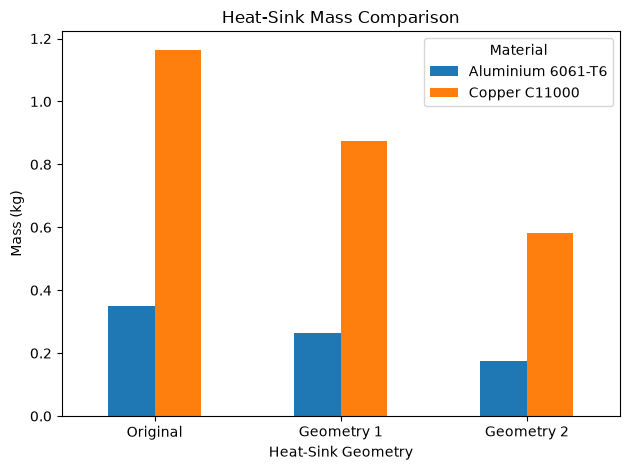

In [3]:
import matplotlib.pyplot as plt

mass_plot = mass_results.pivot(
    index="Geometry",
    columns="Material",
    values="Mass (kg)"
)

mass_plot = mass_plot.reindex([
    "Original",
    "Geometry 1",
    "Geometry 2"
])

mass_plot.plot(kind="bar")

plt.xlabel("Heat-Sink Geometry")
plt.ylabel("Mass (kg)")
plt.title("Heat-Sink Mass Comparison")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

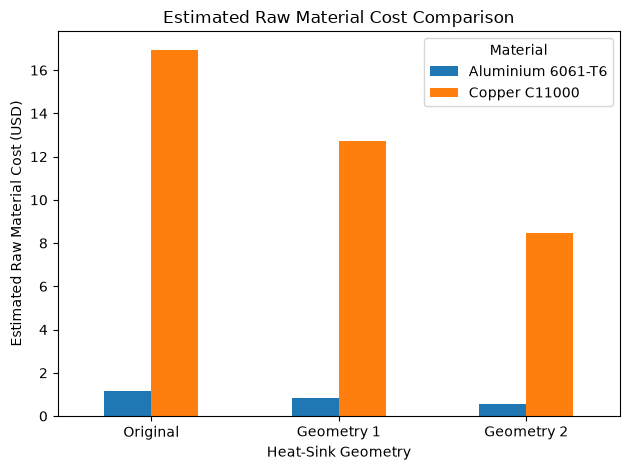

In [4]:
cost_plot = mass_results.pivot(
    index="Geometry",
    columns="Material",
    values="Estimated Raw Material Cost (USD)"
)

cost_plot = cost_plot.reindex([
    "Original",
    "Geometry 1",
    "Geometry 2"
])

cost_plot.plot(kind="bar")

plt.xlabel("Heat-Sink Geometry")
plt.ylabel("Estimated Raw Material Cost (USD)")
plt.title("Estimated Raw Material Cost Comparison")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Manufacturability and Industrial Use

### Aluminium 6061-T6

Aluminium 6061-T6 is well suited to heat-sink manufacture because it combines relatively low density with good machinability and compatibility with extrusion-based manufacturing.

For the present geometries, the fin profile remains broadly similar while the heat-sink length and number of fins vary. In an industrial setting, this type of geometry could potentially be manufactured from a common extruded aluminium profile and then cut to the required length.

This offers several practical advantages:

- lower material mass compared with copper
- relatively straightforward machining after extrusion
- reduced handling and transport mass
- good suitability for repeated production
- easier integration into compact power-electronic assemblies

### Copper

Copper offers substantially higher thermal conductivity, but it is significantly denser than aluminium. For the same heat-sink geometry, the copper design is approximately 3.32 times heavier.

The increased mass creates disadvantages in handling, mounting, transport and enclosure integration. Copper may still be justified in highly temperature-sensitive or space-constrained applications where its greater thermal conductivity provides a sufficiently large thermal benefit.

### Engineering Implication

Material selection should therefore not be based on thermal conductivity alone. The final design should consider junction temperature, heat-sink mass, raw material cost, manufacturability and ease of integration into an industrial converter.

| Factor | Aluminium 6061-T6 | Copper |
|---|---|---|
| Thermal conductivity | Moderate | High |
| Density | Low | High |
| Heat-sink mass | Lower | Much higher |
| Raw material cost | Lower | Higher |
| Extrusion suitability | Very good | More limited/costly |
| Machinability | Good | Good, but heavier |
| Industrial integration | Easier | More demanding |
| Best use case | General heat-sink applications | High heat-flux / space-constrained applications |